# Final Project: Adult Census Income Classification

## Project Objective

The objective of this project is to analyze demographic and employment data and predict whether an individual's annual income exceeds $50,000.

This project follows the complete Data Science workflow:

1. Data Collection
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Data Visualization
5. Feature Engineering
6. Machine Learning Modeling
7. Model Evaluation
8. Streamlit Deployment

Dataset Source:
https://www.kaggle.com/datasets/uciml/adult-census-income

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Dataset Loading

## Research Question

What information does the dataset contain?

The first step is to load the dataset and inspect the first few records to understand its structure and available features.

In [2]:
df = pd.read_csv('adult.csv')
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# Dataset Dimensions

## Question

How many observations and features are available in the dataset?

Understanding the size of the dataset helps determine whether it is suitable for machine learning analysis.

In [3]:
df.shape

(32561, 15)

# Data Types Analysis

## Question

What types of variables exist in the dataset?

The dataset contains both numerical and categorical variables. Understanding data types is important before preprocessing and model building.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


# Descriptive Statistics

## Question

What are the main statistical characteristics of numerical variables?

This section provides information regarding:

- Mean
- Standard Deviation
- Minimum Values
- Maximum Values
- Quartiles

These statistics help identify data distributions and possible anomalies.

In [5]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


# Missing Value Analysis

## Question

Does the dataset contain missing values?

Missing values may negatively affect machine learning algorithms and therefore must be identified and handled appropriately.

In [6]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

# Duplicate Record Analysis

## Question

Are there duplicated records in the dataset?

Duplicate observations may introduce bias into the analysis and model training process.

In [7]:
df.drop_duplicates(inplace=True)

## Exploratory Data Analysis

# Age Distribution Analysis

## Question

How are individuals distributed according to age?

A histogram is used to visualize the frequency distribution of ages in the dataset.

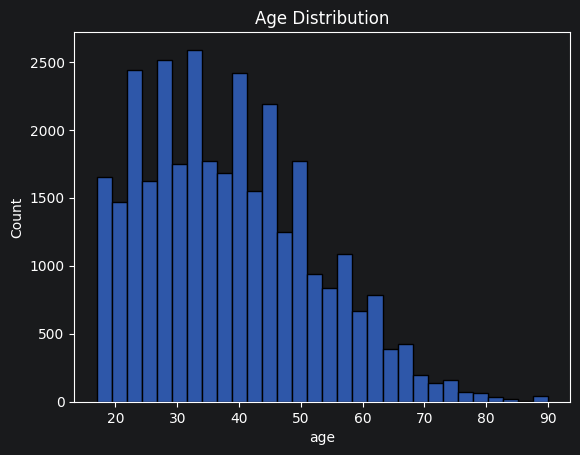

In [8]:
sns.histplot(df['age'], bins=30)
plt.title('Age Distribution')
plt.show()

### Interpretation

The majority of individuals fall between the ages of 25 and 50 years.

This suggests that the dataset is largely composed of working-age adults.

# Target Variable Analysis

## Question

How is income distributed among individuals?

The target variable represents whether annual income exceeds $50,000.

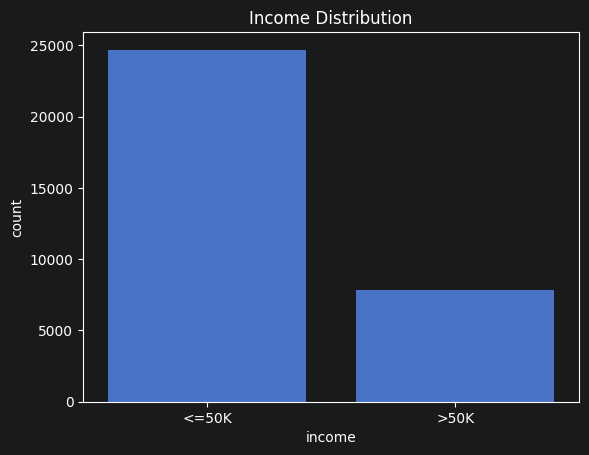

In [9]:
sns.countplot(x='income', data=df)
plt.title('Income Distribution')
plt.show()

# Education Level Analysis

## Question

Which education levels are most common?

Education is expected to have a significant relationship with income level.

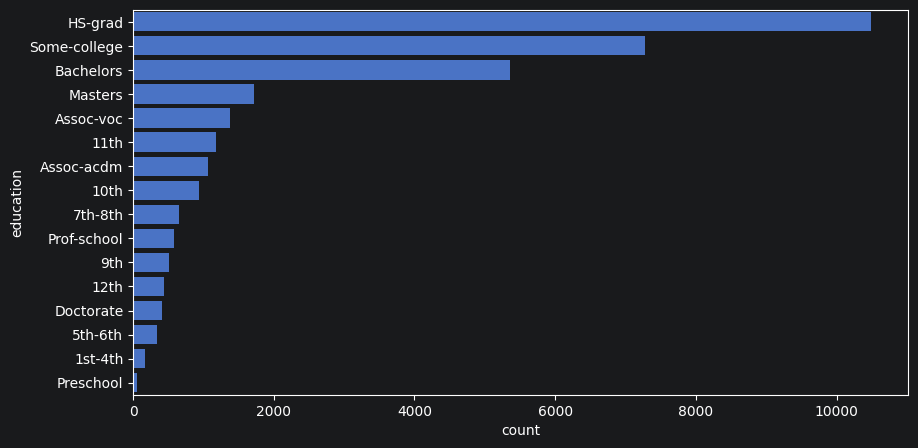

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(y='education', data=df, order=df['education'].value_counts().index)
plt.show()

### Interpretation

Some education categories occur much more frequently than others, indicating differences in educational attainment among individuals.

# Education vs Income

## Question

Does education influence income level?

This visualization compares educational attainment with annual income.

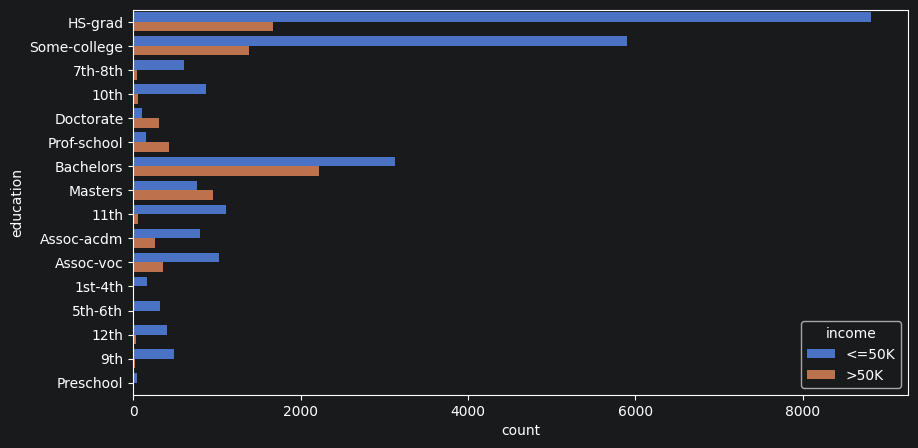

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(y='education', hue='income', data=df)
plt.show()

### Interpretation

Individuals with higher levels of education tend to have a greater probability of earning more than $50,000 annually.

Education appears to be an important predictor.

# Correlation Analysis

## Question

What relationships exist between numerical variables?

A correlation heatmap helps identify positive and negative associations between features.

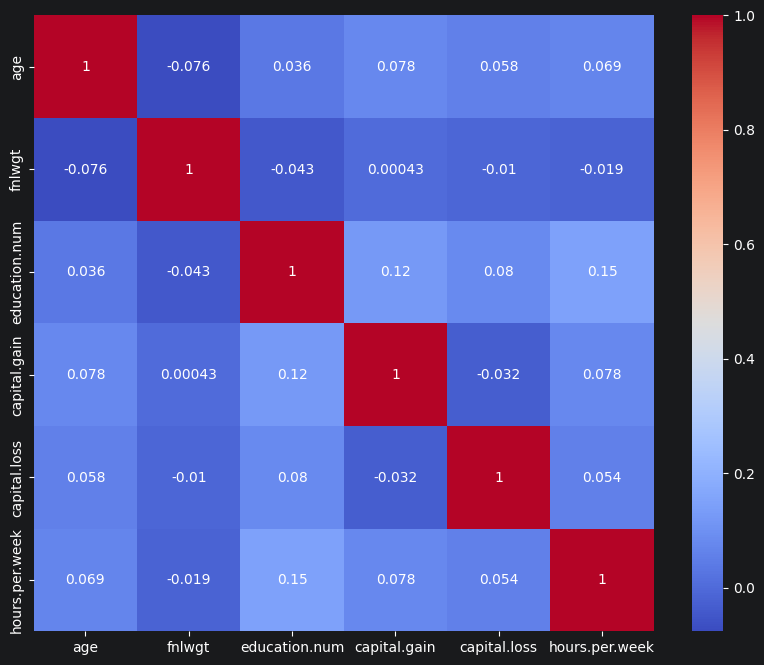

In [12]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

### Interpretation

Variables such as capital gain, education level, and hours worked may show stronger relationships with income.

Highly correlated variables may provide valuable predictive information.

# Feature Selection

## Question

Which variables will be used for prediction?

For this project, the following numerical variables were selected:

- age
- fnlwgt
- education.num
- capital.gain
- capital.loss
- hours.per.week

These features were selected because they are directly related to education, work characteristics and economic status.

In [13]:
print(df.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


# Target Variable Analysis

## Question

How many individuals belong to each income category?

The target variable is analyzed before model training to understand class distribution.

In [14]:
df['income'].value_counts()

income
<=50K    24698
>50K      7839
Name: count, dtype: int64

# Data Preprocessing

Before training machine learning models, the data must be prepared.

## Preprocessing Steps

1. Select important features
2. Encode target variable
3. Split data into training and testing sets
4. Scale numerical features

These steps ensure fair and reliable model evaluation.

# Encoding Categorical Variables

## Question

Why is encoding necessary?

Machine learning algorithms cannot work directly with text values.

Therefore categorical variables such as:

- workclass
- marital.status
- occupation

are converted into numerical representations using Label Encoding.

In [15]:
df[['workclass','marital.status','occupation']].head()

,workclass,marital.status,occupation
0,?,Widowed,?
1,Private,Widowed,Exec-managerial
2,?,Widowed,?
3,Private,Divorced,Machine-op-inspct
4,Private,Separated,Prof-specialty


### Verification

The categorical variables have been successfully transformed into numerical values and are now ready for machine learning.

In [16]:
features = [
    'age',
    'fnlwgt',
    'education.num',
    'capital.gain',
    'capital.loss',
    'hours.per.week',

    'workclass',
    'marital.status',
    'occupation'
]

target = 'income'

from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_columns = [
    'workclass',
    'marital.status',
    'occupation'
]

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

le_target = LabelEncoder()
df[target] = le_target.fit_transform(df[target])

X = df[features]
y = df[target]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model 1: Logistic Regression

## Why Logistic Regression?

Logistic Regression is one of the most widely used classification algorithms.

### Advantages

- Simple and interpretable
- Fast training
- Works well on many classification tasks

### Disadvantages

- Assumes linear relationships
- May underperform on complex datasets

In [18]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print('Accuracy:', accuracy_score(y_test,pred_lr))
print('Precision:', precision_score(y_test,pred_lr))
print('Recall:', recall_score(y_test,pred_lr))
print('F1:', f1_score(y_test,pred_lr))

Accuracy: 0.8154578979717271
Precision: 0.6716899892357373
Recall: 0.4105263157894737
F1: 0.509595753368722


# Hyperparameter Tuning

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50,100],
    'max_depth': [5,10,None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1'
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': None, 'n_estimators': 100}


In [20]:
best_rf = grid.best_estimator_

pred_rf = best_rf.predict(X_test)

# Model 2: Random Forest Classifier

## Why Random Forest?

Random Forest combines multiple decision trees to improve predictive performance.

### Advantages

- High accuracy
- Handles non-linear relationships
- Robust to noise

### Disadvantages

- More computationally expensive
- Less interpretable

In [21]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print('Accuracy:', accuracy_score(y_test,pred_rf))
print('Precision:', precision_score(y_test,pred_rf))
print('Recall:', recall_score(y_test,pred_rf))
print('F1:', f1_score(y_test,pred_rf))

Accuracy: 0.8557160417947142
Precision: 0.7182569496619083
Recall: 0.6289473684210526
F1: 0.6706418800420905


# Feature Importance Analysis

## Question

Which variables contribute the most to income prediction?

Random Forest provides feature importance scores that indicate the relative contribution of each feature.

This analysis helps identify the most influential variables affecting income level.

In [22]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
1,fnlwgt,0.197850
0,age,0.157703
7,marital.status,0.153705
2,education.num,0.130064
3,capital.gain,0.127817
5,hours.per.week,0.081687
8,occupation,0.068462
4,capital.loss,0.041682
6,workclass,0.041030


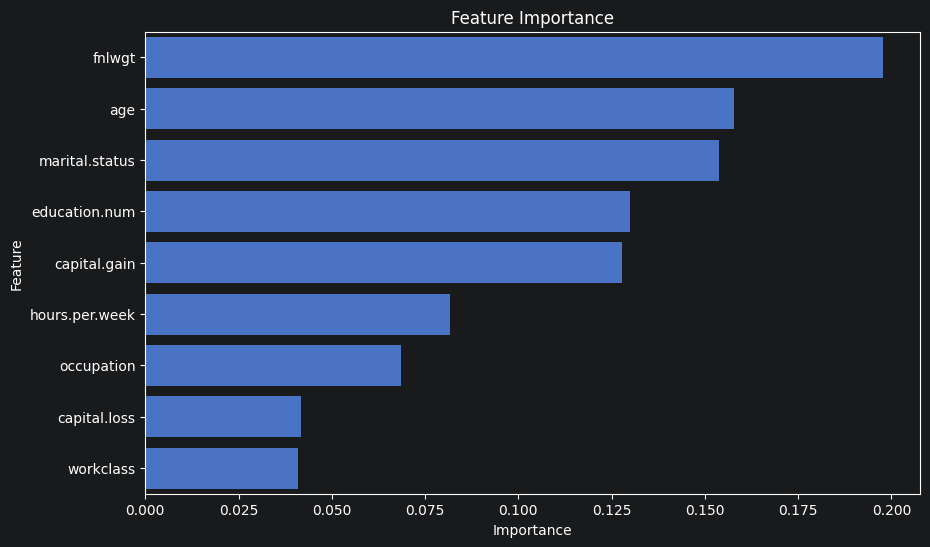

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

In [24]:
results = pd.DataFrame({
'Model':['Logistic Regression','Random Forest'],
'Accuracy':[accuracy_score(y_test,pred_lr),accuracy_score(y_test,pred_rf)],
'Precision':[precision_score(y_test,pred_lr),precision_score(y_test,pred_rf)],
'Recall':[recall_score(y_test,pred_lr),recall_score(y_test,pred_rf)],
'F1':[f1_score(y_test,pred_lr),f1_score(y_test,pred_rf)]
})
results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.815458,0.671690,0.410526,0.509596
1,Random Forest,0.855716,0.718257,0.628947,0.670642


## Evaluation

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score

These metrics provide a comprehensive assessment of classification performance.

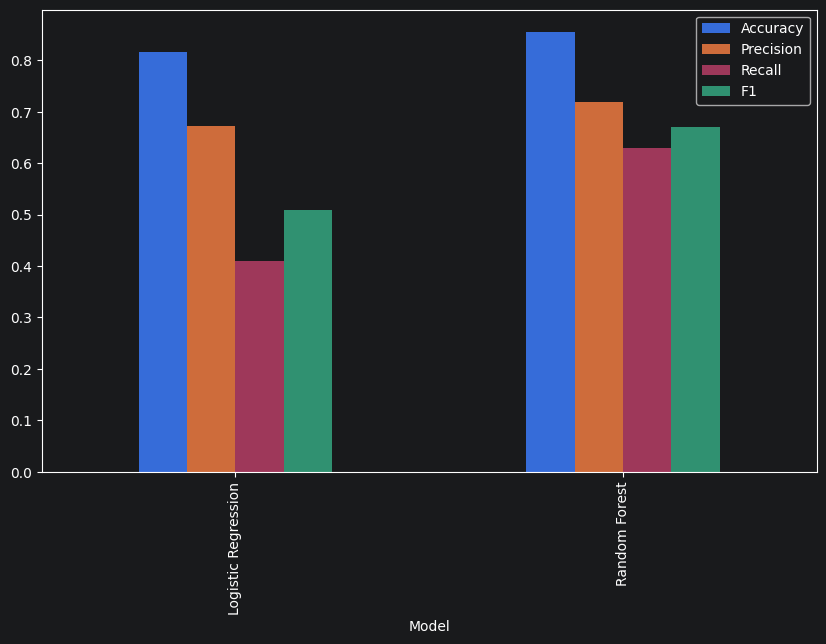

In [25]:
results.set_index('Model').plot(kind='bar', figsize=(10,6))
plt.show()

# Confusion Matrix Analysis

The confusion matrix provides detailed information about:

- True Positives
- True Negatives
- False Positives
- False Negatives

This helps evaluate classification quality beyond accuracy alone.

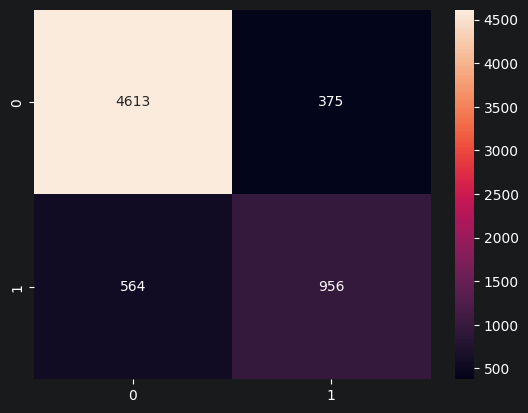

In [26]:
cm = confusion_matrix(y_test,pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

# Pair Plot Analysis

## Question

How are important numerical variables related to each other?

The pair plot visualizes pairwise relationships and distributions among selected numerical variables.

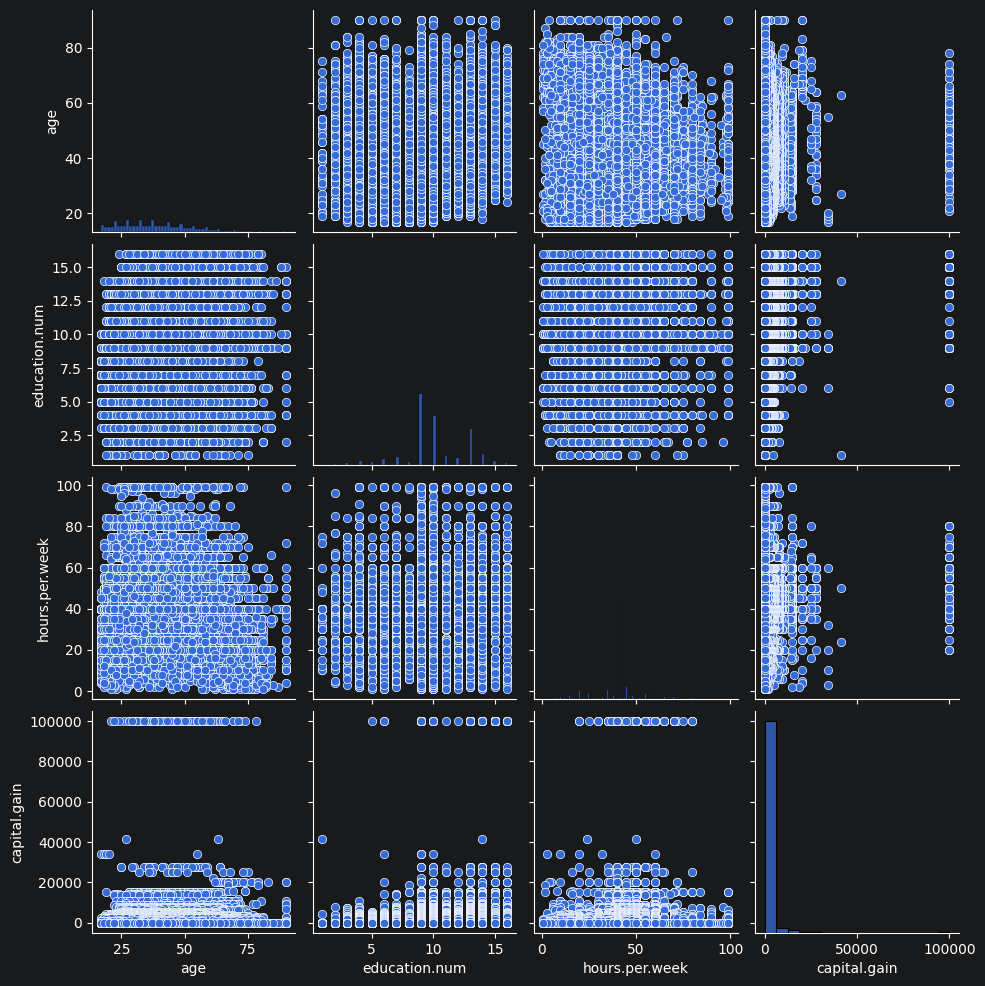

In [27]:
selected_columns = [
    'age',
    'education.num',
    'hours.per.week',
    'capital.gain'
]

sns.pairplot(df[selected_columns])

plt.show()

## Save Model For Streamlit

In [28]:
df_original = pd.read_csv("adult.csv")

print(df_original['workclass'].unique())
print()
print(df_original['marital.status'].unique())
print()
print(df_original['occupation'].unique())

['?' 'Private' 'State-gov' 'Federal-gov' 'Self-emp-not-inc' 'Self-emp-inc'
 'Local-gov' 'Without-pay' 'Never-worked']

['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']

['?' 'Exec-managerial' 'Machine-op-inspct' 'Prof-specialty'
 'Other-service' 'Adm-clerical' 'Craft-repair' 'Transport-moving'
 'Handlers-cleaners' 'Sales' 'Farming-fishing' 'Tech-support'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']


In [29]:
pickle.dump(rf, open('model.pkl','wb'))
pickle.dump(scaler, open('scaler.pkl','wb'))
pickle.dump(encoders, open('encoders.pkl','wb'))

print("Saved model, scaler and encoders.")

Saved model, scaler and encoders.


# Conclusion

## Project Summary

The objective of this project was to analyze demographic and employment-related data and develop a machine learning model capable of predicting whether an individual's annual income exceeds $50,000.

The Adult Census Income dataset was selected because it contains both numerical and categorical variables, making it suitable for exploratory data analysis, visualization, and classification tasks.

The project followed the complete Data Science workflow, including data cleaning, exploratory data analysis, feature engineering, machine learning modeling, model evaluation, and local deployment preparation using Streamlit.

## Data Analysis Findings

Several visualizations were created to better understand the dataset, including histograms, count plots, boxplots, correlation heatmaps, and feature importance analysis.

The analysis revealed that:

* Education level is strongly related to income.
* Occupation and marital status influence earning potential.
* Individuals with higher education levels are more likely to earn more than $50,000 annually.
* Capital gain and hours worked per week are important indicators of income level.
* Both numerical and categorical variables contribute valuable information for prediction.

## Machine Learning Results

Two classification algorithms were implemented and compared:

1. Logistic Regression
2. Random Forest Classifier

### Logistic Regression Results

* Accuracy: 81.55%
* Precision: 67.17%
* Recall: 41.05%
* F1-Score: 50.96%

### Random Forest Results

* Accuracy: 85.57%
* Precision: 71.83%
* Recall: 62.89%
* F1-Score: 67.06%

The results demonstrate that Random Forest significantly outperformed Logistic Regression across most evaluation metrics.

The inclusion of categorical features such as workclass, marital status, and occupation improved model performance considerably, highlighting the importance of combining different types of variables in predictive modeling.

## Best Model

Based on the evaluation metrics, Random Forest was selected as the best-performing model.

The model achieved:

* The highest Accuracy (85.57%)
* The highest Recall (62.89%)
* The highest F1-Score (67.06%)

These results indicate that Random Forest provides a better balance between identifying individuals with higher income and minimizing classification errors.

## Applications

The developed model could be applied in several real-world scenarios, including:

* Labor market analysis
* Economic and demographic studies
* Income prediction systems
* Workforce analytics
* Educational and employment research

## Limitations

Although the model achieved good performance, several limitations remain:

* The dataset represents a specific population and time period.
* Additional socioeconomic variables could improve predictions.
* Some potentially useful features were not included in the final model.
* Further optimization could increase performance.

## Future Work

Future improvements may include:

* Hyperparameter tuning using GridSearchCV
* Feature selection techniques
* Cross-validation
* Testing additional machine learning algorithms such as Support Vector Machines (SVM) and XGBoost
* Deployment of the model to a cloud platform
* Development of a more advanced Streamlit web application

## Final Statement

This project successfully demonstrated the complete Data Science and Machine Learning pipeline, from data preparation and exploratory analysis to model development, evaluation, comparison, and deployment preparation. The Random Forest Classifier achieved the best overall performance and proved to be an effective solution for predicting income levels using demographic and employment-related information.
